# Diagramme in der Statistik – Übersicht

> Quelle: [numiqo.de](https://numiqo.de/tutorial/diagramme)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Diagramme stellen Daten **grafisch** dar und helfen dabei, einen ersten Überblick über
gesammelte Daten zu gewinnen und Informationen leicht verständlich aufzubereiten.

| Diagrammtyp | Skalenniveau | Typischer Einsatz |
|---|---|---|
| **Balkendiagramm** | Nominal / Ordinal | Häufigkeiten von Kategorien |
| **Histogramm** | Metrisch | Häufigkeitsverteilung kontinuierlicher Daten |
| **Streudiagramm** | Metrisch (2 Variablen) | Zusammenhänge zwischen zwei Variablen |
| **Liniendiagramm** | Metrisch / Zeitreihe | Trends und Veränderungen über die Zeit |
| **Boxplot** | Metrisch | Verteilung, Median, Quartile, Ausreißer |
| **Kreisdiagramm** | Nominal / Ordinal | Anteile einer Gesamtheit |

> **Faustregel:** Erst Daten mit Diagrammen visualisieren, dann mit
> Hypothesentests absichern.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Welches Diagramm für welche Daten?

Die Wahl des richtigen Diagramms hängt vom **Skalenniveau** und der **Fragestellung** ab:

```
Skalenniveau der Variable
│
├── NOMINAL / ORDINAL  (Kategorien)
│   ├── Häufigkeiten zeigen     →  Balkendiagramm
│   └── Anteile zeigen          →  Kreisdiagramm
│
└── METRISCH  (kontinuierlich)
    ├── Verteilung zeigen        →  Histogramm
    ├── Zusammenhang (2 Var.)    →  Streudiagramm
    ├── Trend über Zeit          →  Liniendiagramm
    └── Verteilung + Ausreißer   →  Boxplot
```

In [23]:
# Gemeinsame Beispieldaten fuer alle Diagramme

# 1. Kategoriale Daten: Verkehrsmittel zur Uni
verkehrsmittel = pd.Series(
    ["Fahrrad"]*28 + ["OEPC/Bahn"]*35 + ["Auto"]*18 +
    ["zu Fuss"]*12 + ["Motorrad"]*7
)

# 2. Metrische Daten: Pruefungsergebnisse von 150 Studierenden (numiqo-Beispiel)
punkte = pd.Series(np.random.normal(loc=62, scale=14, size=150).clip(0, 100).round(1))

# 3. Zwei metrische Variablen: Koerpergroesse und Gewicht
koerpergroesse = pd.Series(np.random.normal(170, 10, 80).round(1))
gewicht        = 0.55 * koerpergroesse + np.random.normal(0, 6, 80) - 23
gewicht        = gewicht.round(1)

# 4. Zeitreihendaten: Studierende pro Semester
semester = list(range(2018, 2025))
studierende = pd.Series([2100, 2250, 2400, 2300, 2550, 2700, 2850],
                         index=semester)

print("Datensätze erstellt:")
print(f"  verkehrsmittel:  {len(verkehrsmittel)} Beobachtungen")
print(f"  punkte:          {len(punkte)} Beobachtungen")
print(f"  koerpergroesse:  {len(koerpergroesse)} Beobachtungen")
print(f"  studierende:     {len(studierende)} Semester (2018-2024)")

Datensätze erstellt:
  verkehrsmittel:  100 Beobachtungen
  punkte:          150 Beobachtungen
  koerpergroesse:  80 Beobachtungen
  studierende:     7 Semester (2018-2024)


## 2. Balkendiagramm

Das **Balkendiagramm** (auch Säulendiagramm) ist das am häufigsten verwendete Diagramm
in der Statistik.

**Einsatz:**
- Häufigkeiten verschiedener **Kategorien** darstellen
- Numerische Werte je Kategorie vergleichen (z. B. Verkaufszahlen)
- Geeignet für **nominale und ordinale** Variablen

**Merkmale:**
- Jeder Balken ist proportional zum dargestellten Wert
- **Abstand zwischen Balken** (Unterschied zum Histogramm!)
- Kann horizontal oder vertikal angeordnet sein

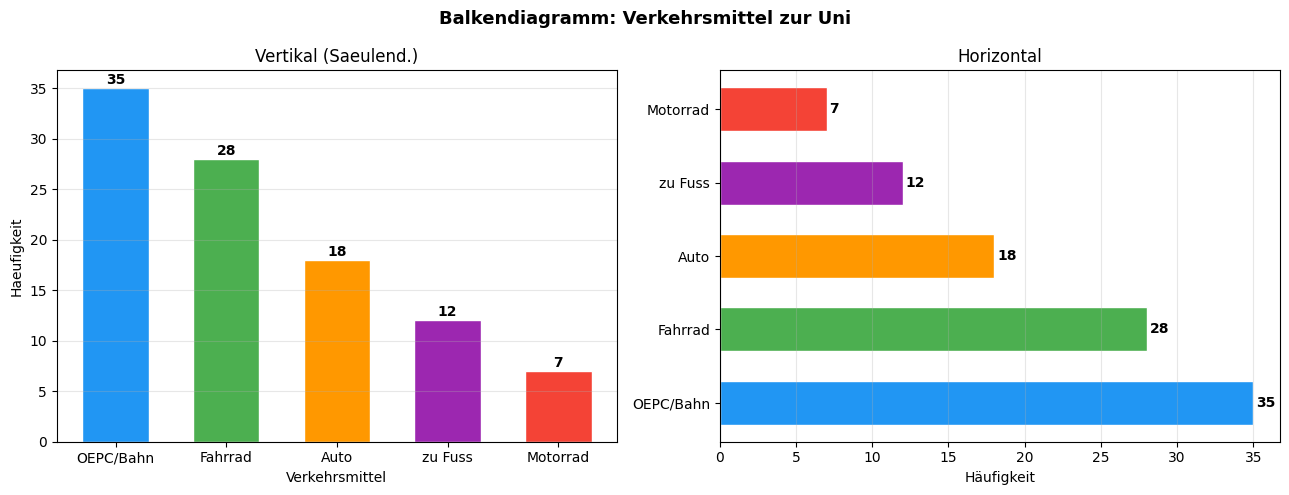

Häufigkeiten:
  OEPC/Bahn   :  35  (35.0%)
  Fahrrad     :  28  (28.0%)
  Auto        :  18  (18.0%)
  zu Fuss     :  12  (12.0%)
  Motorrad    :   7  (7.0%)


In [ ]:
# Balkendiagramm – Verkehrsmittel zur Uni
haeuf = verkehrsmittel.value_counts().sort_values(ascending=False)
farben = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Balkendiagramm: Verkehrsmittel zur Uni", fontsize=13, fontweight="bold")

# Vertikal
axes[0].bar(haeuf.index, haeuf.values, color=farben, edgecolor="white", width=0.6)
axes[0].set_title("Vertikal (Säulend.)")
axes[0].set_xlabel("Verkehrsmittel")
axes[0].set_ylabel("Häufigkeit")
for i, v in enumerate(haeuf.values):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Horizontal
axes[1].barh(haeuf.index, haeuf.values, color=farben, edgecolor="white", height=0.6)
axes[1].set_title("Horizontal")
axes[1].set_xlabel("Häufigkeit")
for i, v in enumerate(haeuf.values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("Häufigkeiten:")
for k, v in haeuf.items():
    print(f"  {k:<12}: {v:>3}  ({v/len(verkehrsmittel)*100:.1f}%)")

## 3. Histogramm

Das **Histogramm** stellt die Häufigkeitsverteilung einer **metrischen Variable** dar.
Die Werte werden dafür in **Klassen (Bins)** eingeteilt.

**Unterschied zum Balkendiagramm:**

| | Balkendiagramm | Histogramm |
|---|---|---|
| Datentyp | Kategorisch (nominal/ordinal) | Metrisch (kontinuierlich) |
| Balken | Mit Abstand | Ohne Abstand (direkt nebeneinander) |
| Einteilung | Bereits in Gruppen | Muss erst in Klassen (Bins) eingeteilt werden |
| Beispiel | Geschlecht, Schulnoten | Alter, Gehalt, Testergebnisse |

**Faustregel Anzahl Bins:** $k \approx \sqrt{n}$

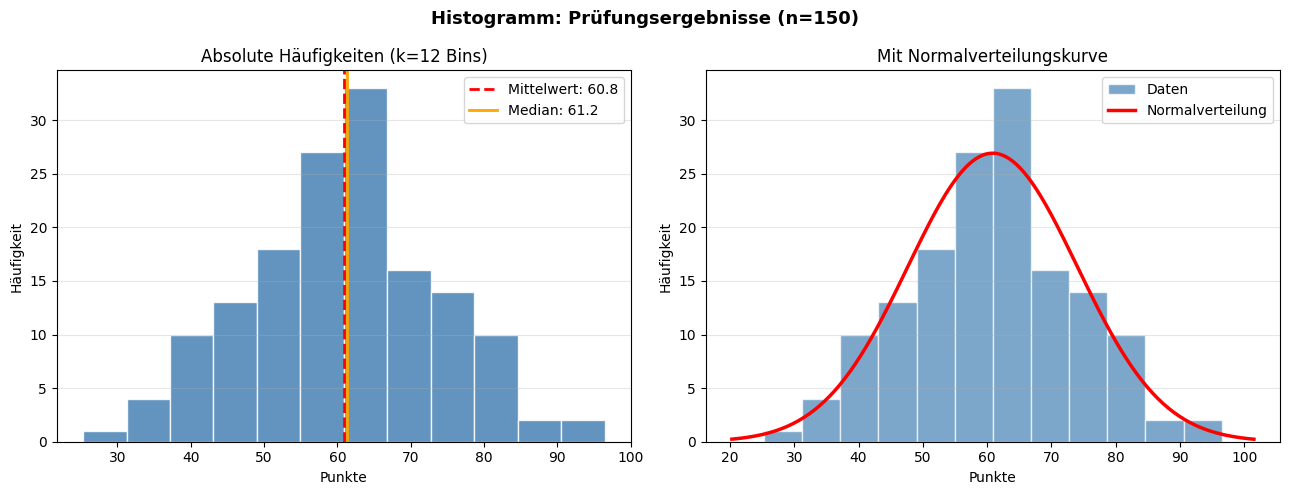

Deskriptive Statistiken:
  n=150, MW=60.85, Median=61.25, SD=13.19
  Min=25.3, Max=96.5


In [12]:
# Histogramm – Prüfungsergebnisse (numiqo-Beispiel: 150 Studierende)
k = int(np.sqrt(len(punkte)))   # Faustregel: k = sqrt(n)
mw = punkte.mean()
med = punkte.median()
sd = punkte.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Histogramm: Prüfungsergebnisse (n=150)", fontsize=13, fontweight="bold")

# Standard-Histogramm
axes[0].hist(punkte, bins=k, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(mw,  color="red",    linestyle="--", linewidth=2,
                label=f"Mittelwert: {mw:.1f}")
axes[0].axvline(med, color="orange", linestyle="-",  linewidth=2,
                label=f"Median: {med:.1f}")
axes[0].set_title(f"Absolute Häufigkeiten (k={k} Bins)")
axes[0].set_xlabel("Punkte")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Histogramm mit Normalverteilungskurve
x_range = np.linspace(punkte.min()-5, punkte.max()+5, 300)
y_norm  = stats.norm.pdf(x_range, mw, sd) * len(punkte) * (punkte.max()-punkte.min())/k
axes[1].hist(punkte, bins=k, color="steelblue", edgecolor="white", alpha=0.7,
             label="Daten")
axes[1].plot(x_range, y_norm, color="red", linewidth=2.5,
             label="Normalverteilung")
axes[1].set_title("Mit Normalverteilungskurve")
axes[1].set_xlabel("Punkte")
axes[1].set_ylabel("Häufigkeit")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Deskriptive Statistiken:")
print(f"  n={len(punkte)}, MW={mw:.2f}, Median={med:.2f}, SD={sd:.2f}")
print(f"  Min={punkte.min():.1f}, Max={punkte.max():.1f}")

## 4. Streudiagramm

Das **Streudiagramm** (auch Scatterplot) stellt den Zusammenhang zwischen **zwei
metrischen Variablen** dar. Jedes Wertepaar einer Person wird als Punkt im
Koordinatensystem eingetragen.

**Mögliche Zusammenhänge:**

| Muster | Zusammenhang |
|---|---|
| Punkte steigen von links nach rechts | **Positiver** Zusammenhang |
| Punkte fallen von links nach rechts | **Negativer** Zusammenhang |
| Punkte zufällig verteilt | **Kein** linearer Zusammenhang |
| Kurvenförmiges Muster | **Nichtlinearer** Zusammenhang |

**Beispiel:** Körpergröße und Gewicht – hohe Körpergröße geht tendenziell mit
höherem Gewicht einher → positiver Zusammenhang.

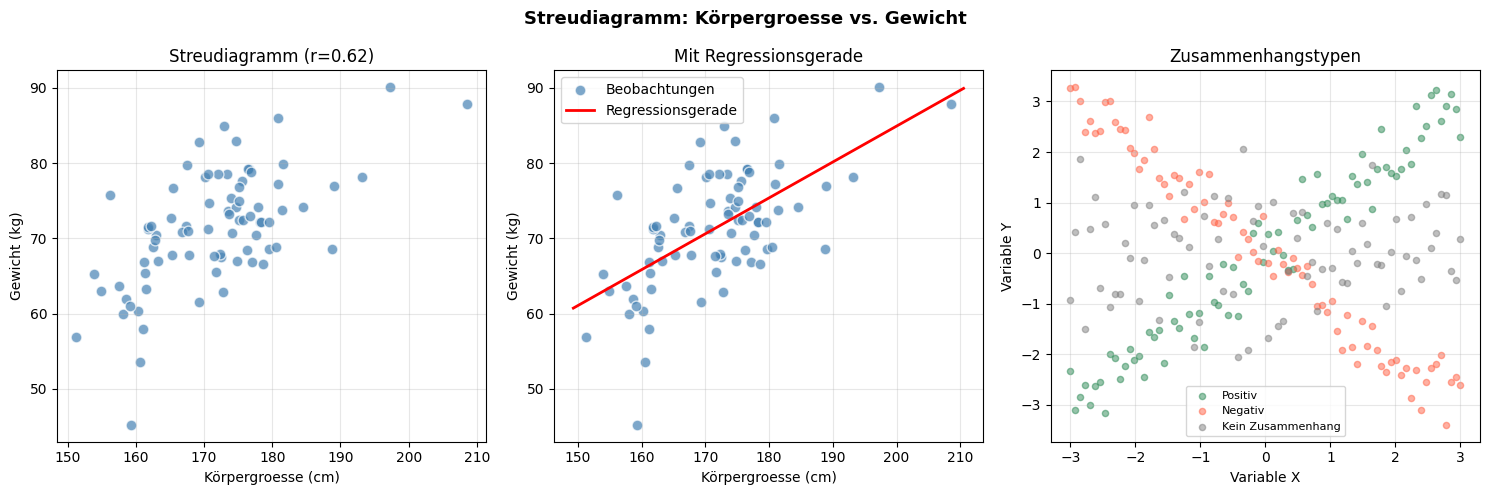

Pearson-Korrelation r = 0.622 (positiver Zusammenhang)


In [15]:
# Streudiagramm – Koerpergroesse und Gewicht
korr = np.corrcoef(koerpergroesse, gewicht)[0, 1]

# Regressionslinie
m, b = np.polyfit(koerpergroesse, gewicht, 1)
x_line = np.linspace(koerpergroesse.min()-2, koerpergroesse.max()+2, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Streudiagramm: Körpergroesse vs. Gewicht", fontsize=13, fontweight="bold")

# 1. Einfaches Streudiagramm
axes[0].scatter(koerpergroesse, gewicht, color="steelblue",
                alpha=0.7, edgecolors="white", s=60)
axes[0].set_title(f"Streudiagramm (r={korr:.2f})")
axes[0].set_xlabel("Körpergroesse (cm)")
axes[0].set_ylabel("Gewicht (kg)")
axes[0].grid(alpha=0.3)

# 2. Mit Regressionsgerade
axes[1].scatter(koerpergroesse, gewicht, color="steelblue",
                alpha=0.7, edgecolors="white", s=60, label="Beobachtungen")
axes[1].plot(x_line, m*x_line+b, color="red", linewidth=2,
             label=f"Regressionsgerade")
axes[1].set_title("Mit Regressionsgerade")
axes[1].set_xlabel("Körpergroesse (cm)")
axes[1].set_ylabel("Gewicht (kg)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Verschiedene Zusammenhangstypen
np.random.seed(7)
x_demo = np.linspace(-3, 3, 80)
demo_daten = [
    (x_demo + np.random.normal(0, 0.4, 80),  "Positiv"),
    (-x_demo + np.random.normal(0, 0.4, 80), "Negativ"),
    (np.random.normal(0, 1, 80),              "Kein Zusammenhang"),
]
farben_demo = ["seagreen", "tomato", "gray"]
for (y_d, lbl), fc in zip(demo_daten, farben_demo):
    axes[2].scatter(x_demo, y_d, color=fc, alpha=0.5, s=20, label=lbl)
axes[2].set_title("Zusammenhangstypen")
axes[2].set_xlabel("Variable X")
axes[2].set_ylabel("Variable Y")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Pearson-Korrelation r = {korr:.3f} (positiver Zusammenhang)")

## 5. Liniendiagramm

Das **Liniendiagramm** verbindet Datenpunkte durch eine Linie und eignet sich besonders
für die Darstellung von **Trends und Veränderungen über die Zeit**.

**Einsatz:**
- Zeitreihen (Umsatz, Temperatur, Kurse, …)
- Kontinuierliche Veränderungen sichtbar machen
- Mehrere Gruppen im Zeitverlauf vergleichen

**Aufbau:**
- Horizontale Achse: Zeit (oder andere kontinuierliche Variable)
- Vertikale Achse: Messwert

C:\Users\JuliaBruzkaja\AppData\Local\Temp\ipykernel_100008\320458534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(sem_labels, rotation=30, ha="right")
C:\Users\JuliaBruzkaja\AppData\Local\Temp\ipykernel_100008\320458534.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sem_labels, rotation=30, ha="right")


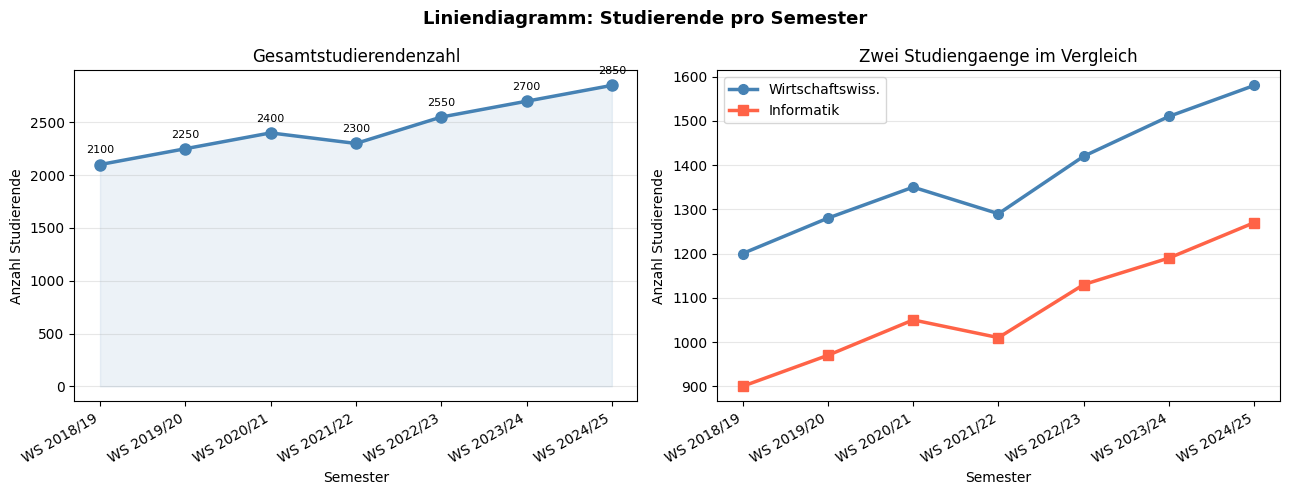

In [ ]:
# Liniendiagramm – Studierende pro Semester + zwei Studiengänge
np.random.seed(3)
sem_labels = [f"WS {y}/{str(y+1)[-2:]}" for y in range(2018, 2025)]
gruppe_a = pd.Series([1200, 1280, 1350, 1290, 1420, 1510, 1580], index=sem_labels)
gruppe_b = pd.Series([900,  970, 1050, 1010, 1130, 1190, 1270], index=sem_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Liniendiagramm: Studierende pro Semester", fontsize=13, fontweight="bold")

# Einfach
axes[0].plot(sem_labels, studierende.values, marker="o", color="steelblue",
             linewidth=2.5, markersize=8, label="Gesamt")
axes[0].fill_between(sem_labels, studierende.values, alpha=0.1, color="steelblue")
axes[0].set_title("Gesamtstudierendenzahl")
axes[0].set_xlabel("Semester")
axes[0].set_ylabel("Anzahl Studierende")
axes[0].set_xticklabels(sem_labels, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.3)
for x, y in zip(sem_labels, studierende.values):
    axes[0].annotate(str(y), (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

# Zwei Gruppen
axes[1].plot(sem_labels, gruppe_a.values, marker="o", color="steelblue",
             linewidth=2.5, markersize=7, label="Wirtschaftswiss.")
axes[1].plot(sem_labels, gruppe_b.values, marker="s", color="tomato",
             linewidth=2.5, markersize=7, label="Informatik")
axes[1].set_title("Zwei Studiengänge im Vergleich")
axes[1].set_xlabel("Semester")
axes[1].set_ylabel("Anzahl Studierende")
axes[1].set_xticklabels(sem_labels, rotation=30, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Boxplot

Der **Boxplot** (auch Box-Whisker-Plot) gibt eine visuelle Zusammenfassung der
Verteilung einer metrischen Variable – mit **Median, Quartilen und Ausreißern** in
einer einzigen Grafik.

**Aufbau:**

```
    |           |
  --+---[  BOX  ]---+--    •  Ausreißer
    |           |
  Q1            Q3

  ├── IQR ──────┤
  Min*          Max*

  * Whisker = Q1 - 1.5×IQR  bis  Q3 + 1.5×IQR
```

| Element | Beschreibung |
|---|---|
| **Linie in der Box** | Median (Q2) |
| **Untere Boxkante** | Q1 (25. Perzentil) |
| **Obere Boxkante** | Q3 (75. Perzentil) |
| **Box** | IQR = Q3 − Q1 (mittlere 50 % der Daten) |
| **Whisker** | Reichen bis Q1−1,5×IQR bzw. Q3+1,5×IQR |
| **Punkte außerhalb** | Ausreißer |

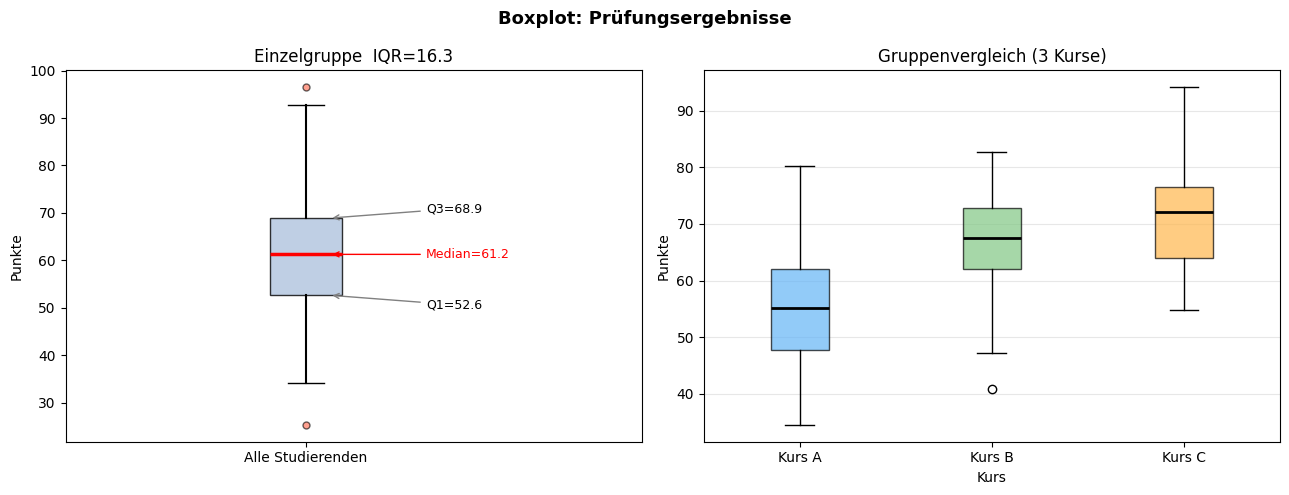

In [18]:
# Boxplot – Prüfungsergebnisse nach Gruppe
np.random.seed(42)
gruppe_1 = pd.Series(np.random.normal(58, 12, 50).clip(0, 100))
gruppe_2 = pd.Series(np.random.normal(67, 10, 50).clip(0, 100))
gruppe_3 = pd.Series(np.random.normal(72,  9, 50).clip(0, 100))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Boxplot: Prüfungsergebnisse", fontsize=13, fontweight="bold")

# Einfacher Boxplot mit Annotation
bp = axes[0].boxplot(punkte, patch_artist=True, vert=True,
                     boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                     medianprops=dict(color="red", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5),
                     flierprops=dict(marker="o", markerfacecolor="tomato",
                                     markersize=5, alpha=0.6))
q1, med_v, q3 = punkte.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
axes[0].annotate(f"Median={med_v:.1f}", xy=(1.05, med_v), xytext=(1.25, med_v),
                 fontsize=9, color="red", va="center",
                 arrowprops=dict(arrowstyle="->", color="red"))
axes[0].annotate(f"Q3={q3:.1f}", xy=(1.05, q3), xytext=(1.25, q3+2),
                 fontsize=9, va="center",
                 arrowprops=dict(arrowstyle="->", color="gray"))
axes[0].annotate(f"Q1={q1:.1f}", xy=(1.05, q1), xytext=(1.25, q1-2),
                 fontsize=9, va="center",
                 arrowprops=dict(arrowstyle="->", color="gray"))
axes[0].set_title(f"Einzelgruppe  IQR={iqr:.1f}")
axes[0].set_ylabel("Punkte")
axes[0].set_xticklabels(["Alle Studierenden"])
axes[0].set_xlim(0.5, 1.7)

# Gruppenvergleich
daten_gruppen = [gruppe_1.values, gruppe_2.values, gruppe_3.values]
bp2 = axes[1].boxplot(daten_gruppen, patch_artist=True,
                      boxprops=dict(alpha=0.7),
                      medianprops=dict(color="black", linewidth=2))
farben_bp = ["#64B5F6", "#81C784", "#FFB74D"]
for patch, farbe in zip(bp2["boxes"], farben_bp):
    patch.set_facecolor(farbe)
axes[1].set_title("Gruppenvergleich (3 Kurse)")
axes[1].set_xlabel("Kurs")
axes[1].set_ylabel("Punkte")
axes[1].set_xticklabels(["Kurs A", "Kurs B", "Kurs C"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Kreisdiagramm

Das **Kreisdiagramm** (auch Tortendiagramm) stellt die Anteile von Kategorien an einer
Gesamtheit dar.

**Wann Kreisdiagramm, wann Balkendiagramm?**

| | Kreisdiagramm | Balkendiagramm |
|---|---|---|
| Anteile einer Gesamtheit zeigen | ✅ gut | ✅ auch möglich |
| Einzelne Werte vergleichen | ❌ schwer | ✅ besser |
| Viele Kategorien (> 5) | ❌ unübersichtlich | ✅ besser |
| Empfehlung numiqo | Wenige Kategorien (2–4) | Standard-Wahl |

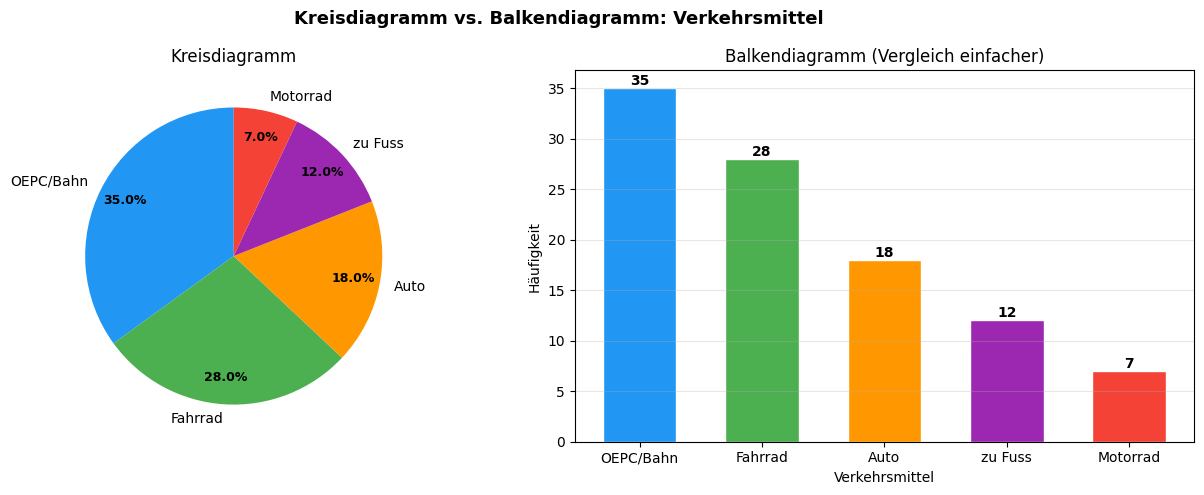

In [20]:
# Kreisdiagramm – Verkehrsmittel zur Uni
haeuf_kreis = verkehrsmittel.value_counts()
farben_kreis = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Kreisdiagramm vs. Balkendiagramm: Verkehrsmittel", fontsize=13, fontweight="bold")

# Kreisdiagramm
wedges, texts, autotexts = axes[0].pie(
    haeuf_kreis.values,
    labels=haeuf_kreis.index,
    autopct="%1.1f%%",
    colors=farben_kreis,
    startangle=90,
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
axes[0].set_title("Kreisdiagramm")

# Balkendiagramm zum Vergleich
axes[1].bar(haeuf_kreis.index, haeuf_kreis.values,
            color=farben_kreis, edgecolor="white", width=0.6)
axes[1].set_title("Balkendiagramm (Vergleich einfacher)")
axes[1].set_xlabel("Verkehrsmittel")
axes[1].set_ylabel("Häufigkeit")
for i, v in enumerate(haeuf_kreis.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

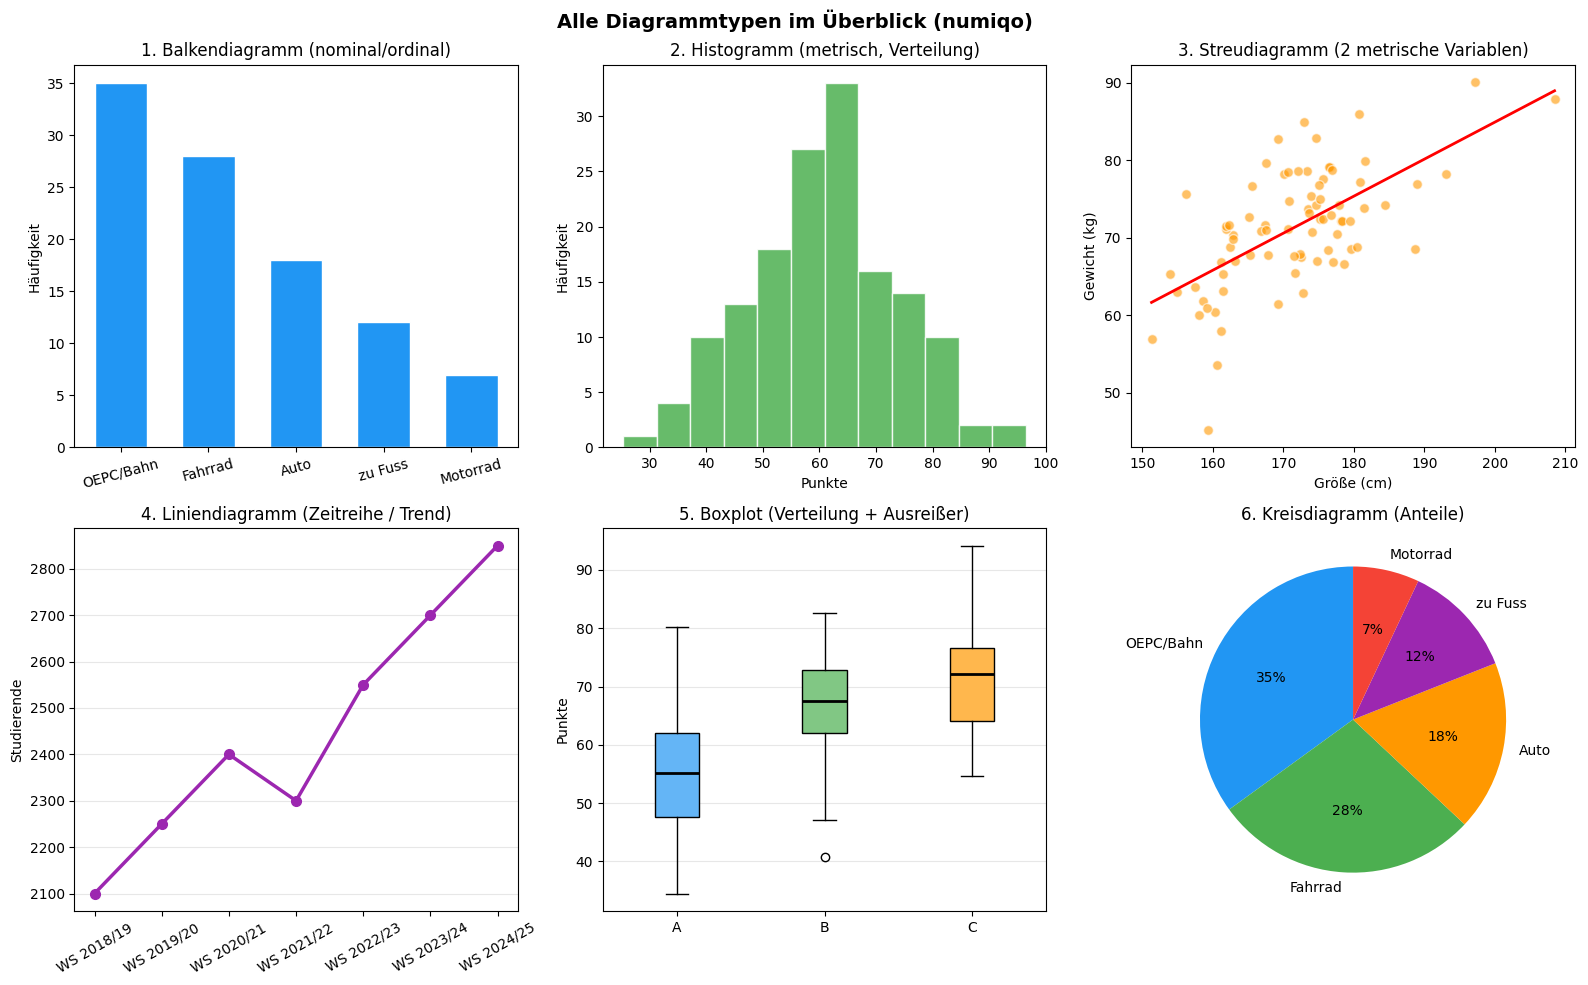

In [22]:
# Alle 6 Diagrammtypen auf einen Blick
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Alle Diagrammtypen im Überblick (numiqo)", fontsize=14, fontweight="bold")

# 1. Balkendiagramm
hf = verkehrsmittel.value_counts()
axes[0,0].bar(hf.index, hf.values, color="#2196F3", edgecolor="white", width=0.6)
axes[0,0].set_title("1. Balkendiagramm (nominal/ordinal)")
axes[0,0].set_ylabel("Häufigkeit")
axes[0,0].tick_params(axis="x", rotation=15)

# 2. Histogramm
axes[0,1].hist(punkte, bins=int(np.sqrt(len(punkte))),
               color="#4CAF50", edgecolor="white", alpha=0.85)
axes[0,1].set_title("2. Histogramm (metrisch, Verteilung)")
axes[0,1].set_xlabel("Punkte")
axes[0,1].set_ylabel("Häufigkeit")

# 3. Streudiagramm
axes[0,2].scatter(koerpergroesse, gewicht, color="#FF9800",
                  alpha=0.6, edgecolors="white", s=50)
m2, b2 = np.polyfit(koerpergroesse, gewicht, 1)
xl = np.linspace(koerpergroesse.min(), koerpergroesse.max(), 100)
axes[0,2].plot(xl, m2*xl+b2, color="red", linewidth=2)
axes[0,2].set_title("3. Streudiagramm (2 metrische Variablen)")
axes[0,2].set_xlabel("Größe (cm)")
axes[0,2].set_ylabel("Gewicht (kg)")

# 4. Liniendiagramm
axes[1,0].plot(sem_labels, studierende.values, marker="o",
               color="#9C27B0", linewidth=2.5, markersize=7)
axes[1,0].set_title("4. Liniendiagramm (Zeitreihe / Trend)")
axes[1,0].set_ylabel("Studierende")
axes[1,0].tick_params(axis="x", rotation=30)
axes[1,0].grid(axis="y", alpha=0.3)

# 5. Boxplot
bp3 = axes[1,1].boxplot([gruppe_1, gruppe_2, gruppe_3], patch_artist=True,
                         medianprops=dict(color="black", linewidth=2))
for patch, fc in zip(bp3["boxes"], ["#64B5F6","#81C784","#FFB74D"]):
    patch.set_facecolor(fc)
axes[1,1].set_title("5. Boxplot (Verteilung + Ausreißer)")
axes[1,1].set_xticklabels(["A","B","C"])
axes[1,1].set_ylabel("Punkte")
axes[1,1].grid(axis="y", alpha=0.3)

# 6. Kreisdiagramm
axes[1,2].pie(hf.values, labels=hf.index, autopct="%1.0f%%",
              colors=["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"],
              startangle=90)
axes[1,2].set_title("6. Kreisdiagramm (Anteile)")

plt.tight_layout()
plt.show()

## 8. Zusammenfassung

```
Diagramme in der Statistik – Entscheidungshilfe
│
├── KATEGORIALE DATEN (nominal/ordinal)
│   ├── Häufigkeiten vergleichen  →  Balkendiagramm  ← Standard-Empfehlung
│   └── Anteile zeigen             →  Kreisdiagramm  (max. 4-5 Kategorien)
│
└── METRISCHE DATEN (kontinuierlich)
    ├── Verteilung einer Variable  →  Histogramm
    │   (Bins: k ≈ √n)
    ├── Zusammenhang 2 Variablen   →  Streudiagramm
    │   (+ Regressionsgerade fuer linearen Trend)
    ├── Trend ueber Zeit           →  Liniendiagramm
    └── Verteilung + Ausreißer     →  Boxplot
        (Median, Q1, Q3, IQR, Whisker = ±1.5×IQR)
```

| Diagramm | Skalenniveau | Zeigt | Python |
|---|---|---|---|
| Balkendiagramm | Nominal/Ordinal | Häufigkeiten | `ax.bar()` |
| Histogramm | Metrisch | Verteilung | `ax.hist()` |
| Streudiagramm | Metrisch (2 Var.) | Zusammenhang | `ax.scatter()` |
| Liniendiagramm | Metrisch/Zeit | Trend | `ax.plot()` |
| Boxplot | Metrisch | Lage + Streuung | `ax.boxplot()` |
| Kreisdiagramm | Nominal/Ordinal | Anteile | `ax.pie()` |

> **Tipp:** Erst Diagramme erstellen → visuellen Eindruck gewinnen →
> dann mit statistischen Tests absichern.

---
Quelle: [numiqo.de/tutorial/diagramme](https://numiqo.de/tutorial/diagramme)